# 37 — Two-Body Measurement Specification

**Repo:** `decoherence-free-sensing`  
**Notebook role:** measurement-protocol layer  
**Previous:** `29_quantum_fisher_specification.ipynb`  
**Next:** `43_preparation_protocols.ipynb`

Notebook 29 quantified the retained differential sensitivity through Quantum Fisher Information. Notebook 37 asks the next engineering question:

> Which measurement extracts that information as a usable phase estimate?

A precision resource becomes an experimental protocol only after a DFS-compatible observable is specified.


## Engineering statement

Quantum Fisher Information specifies achievable precision.

Two-body measurements specify how that precision becomes an experimental readout.


## Key equations

Common and differential generators:

\[
J_z^+ = J_z^{(A)} + J_z^{(B)},
\qquad
J_z^- = J_z^{(A)} - J_z^{(B)}.
\]

DFS compatibility:

\[
J_z^+|\psi\rangle = 0,
\qquad
[M,J_z^+] = 0.
\]

Differential phase encoding:

\[
|\psi(\varphi)\rangle = e^{-i\varphi J_z^-}|\psi_0\rangle.
\]

Two-body observable:

\[
M
=
J_x^{(A)}J_x^{(B)}
+
J_y^{(A)}J_y^{(B)}.
\]

Equivalent ladder-operator form:

\[
M
=
\frac{1}{2}
\left(
J_A^+J_B^-
+
J_A^-J_B^+
\right).
\]

Proxy fringe model with maximum slope at \(\varphi=\pi/4\):

\[
\langle M\rangle(\varphi)=\sin(2\varphi-\pi/2).
\]

Error propagation:

\[
\Delta^2\varphi
=
\frac{\Delta^2 M}
{\left|\partial_\varphi\langle M\rangle\right|^2}.
\]


## Notebook outputs

Running this notebook creates:

- `results/figures/37_two_body_measurement_specification_final.png`
- `results/figures/37_two_body_fringe_response_final.png`
- `results/figures/37_measurement_slope_final.png`
- `results/figures/37_operating_regimes_final.png`
- `results/figures/37_measurement_readout_final.png`
- `results/figures/37_phase_uncertainty_proxy_final.png`
- `results/two_body_measurement_summary.csv`
- `results/two_body_measurement_summary.json`
- `results/decoherence_free_sensing_two_body_measurements_outputs.zip`


In [51]:
from pathlib import Path
import json
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import FileLink, display

ROOT = Path.cwd()
RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"

for path in [RESULTS, FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 220,
    "font.size": 14,
    "axes.titlesize": 22,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
})

def savefig(name):
    path = FIGURES / name
    plt.savefig(path, bbox_inches="tight")
    return path

def draw_box_flow(title, boxes, footer, filename, figsize=(13, 5.8)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title, pad=24)

    n = len(boxes)
    margin = 0.04
    gap = 0.025
    box_w = (1 - 2 * margin - gap * (n - 1)) / n
    box_h = 0.42
    y = 0.43

    for i, box in enumerate(boxes):
        x = margin + i * (box_w + gap)
        patch = FancyBboxPatch(
            (x, y), box_w, box_h,
            boxstyle="round,pad=0.025,rounding_size=0.045",
            linewidth=2.0,
            edgecolor="black",
            facecolor=box.get("facecolor", "white"),
        )
        ax.add_patch(patch)
        ax.text(
            x + box_w/2, y + box_h*0.68, box["title"],
            ha="center", va="center", weight="bold", fontsize=16
        )
        ax.text(
            x + box_w/2, y + box_h*0.36, box.get("body", ""),
            ha="center", va="center", fontsize=12
        )
        if i < n - 1:
            start = (x + box_w - 0.005, y + box_h/2)
            end = (x + box_w + gap + 0.005, y + box_h/2)
            arrow = FancyArrowPatch(
                start, end,
                arrowstyle="-|>", mutation_scale=20,
                linewidth=2.0,
                shrinkA=0, shrinkB=0,
            )
            ax.add_patch(arrow)

    ax.text(0.5, 0.15, footer, ha="center", va="center", fontsize=15)
    path = savefig(filename)
    plt.show()
    return path


## 1. Two-body measurement specification

The state is already constrained to the DFS. The useful phase is generated by \(J_z^-\).

The remaining task is to choose a DFS-compatible observable \(M\), compute its fringe response, and operate where the response slope is largest.


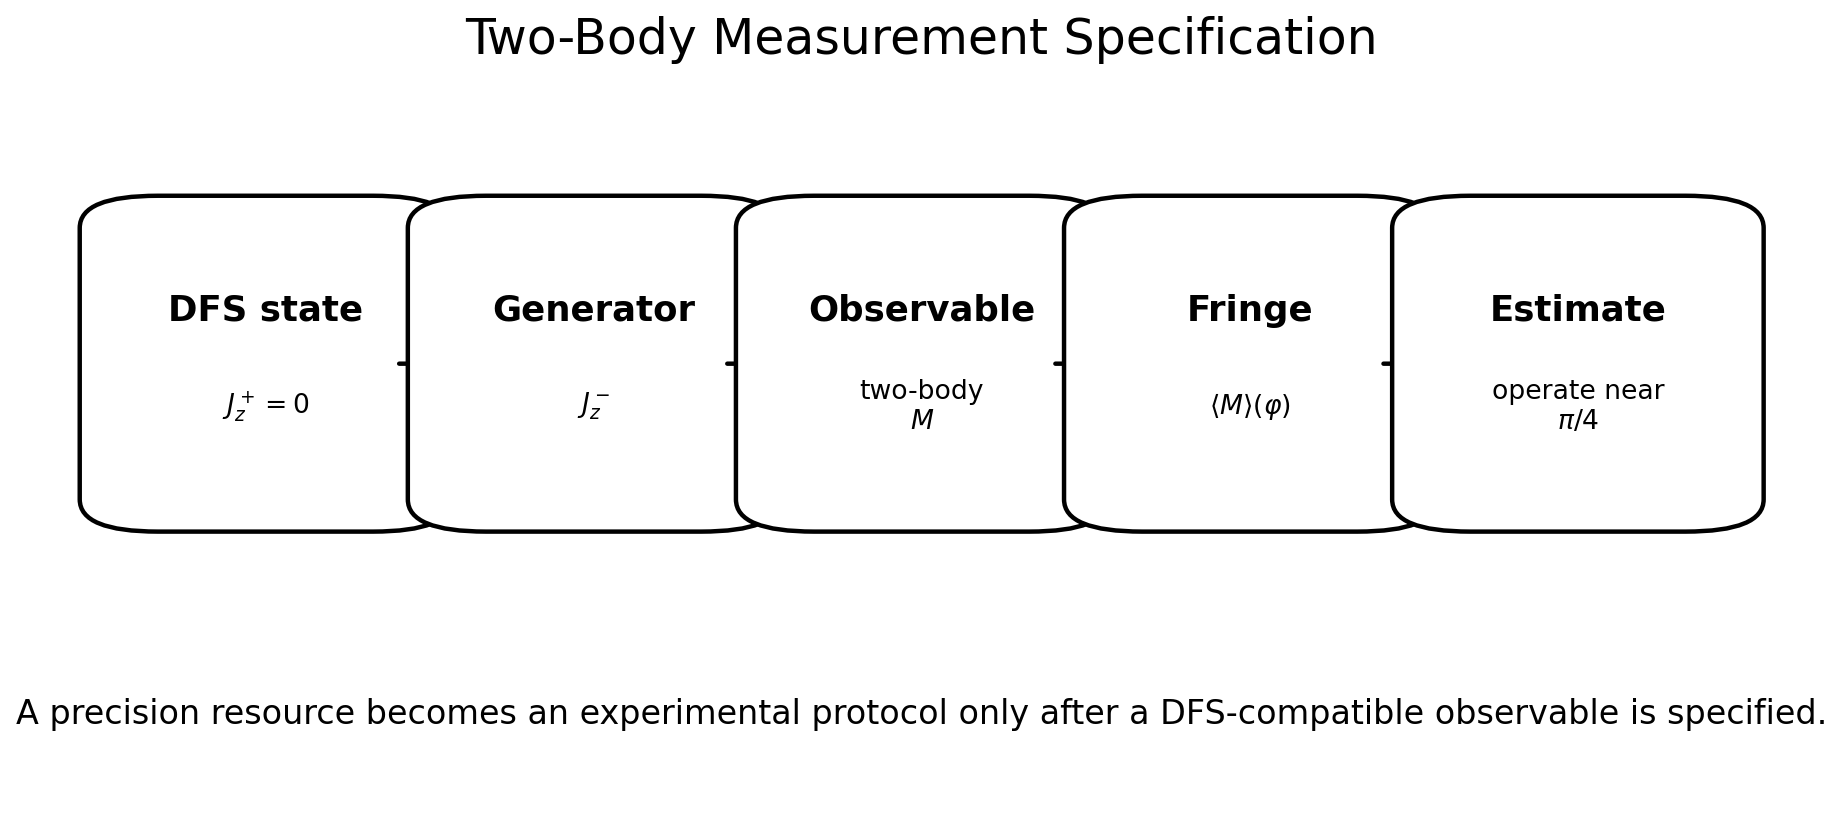

PosixPath('/content/results/figures/37_two_body_measurement_specification_final.png')

In [52]:
draw_box_flow(
    title="Two-Body Measurement Specification",
    boxes=[
        {"title": "DFS state", "body": r"$J_z^+=0$"},
        {"title": "Generator", "body": r"$J_z^-$"},
        {"title": "Observable", "body": "two-body\n$M$"},
        {"title": "Fringe", "body": r"$\langle M\rangle(\varphi)$"},
        {"title": "Estimate", "body": "operate near\n$\\pi/4$"},
    ],
    footer="A precision resource becomes an experimental protocol only after a DFS-compatible observable is specified.",
    filename="37_two_body_measurement_specification_final.png",
    figsize=(14, 5.8),
)


## 2. Proxy two-body fringe

For a compact readout model, use the normalized fringe

\[
\langle M\rangle(\varphi)=\sin(2\varphi-\pi/2).
\]

This convention places the steepest point at \(\varphi=\pi/4\), so the figure directly marks the experimental bias point.


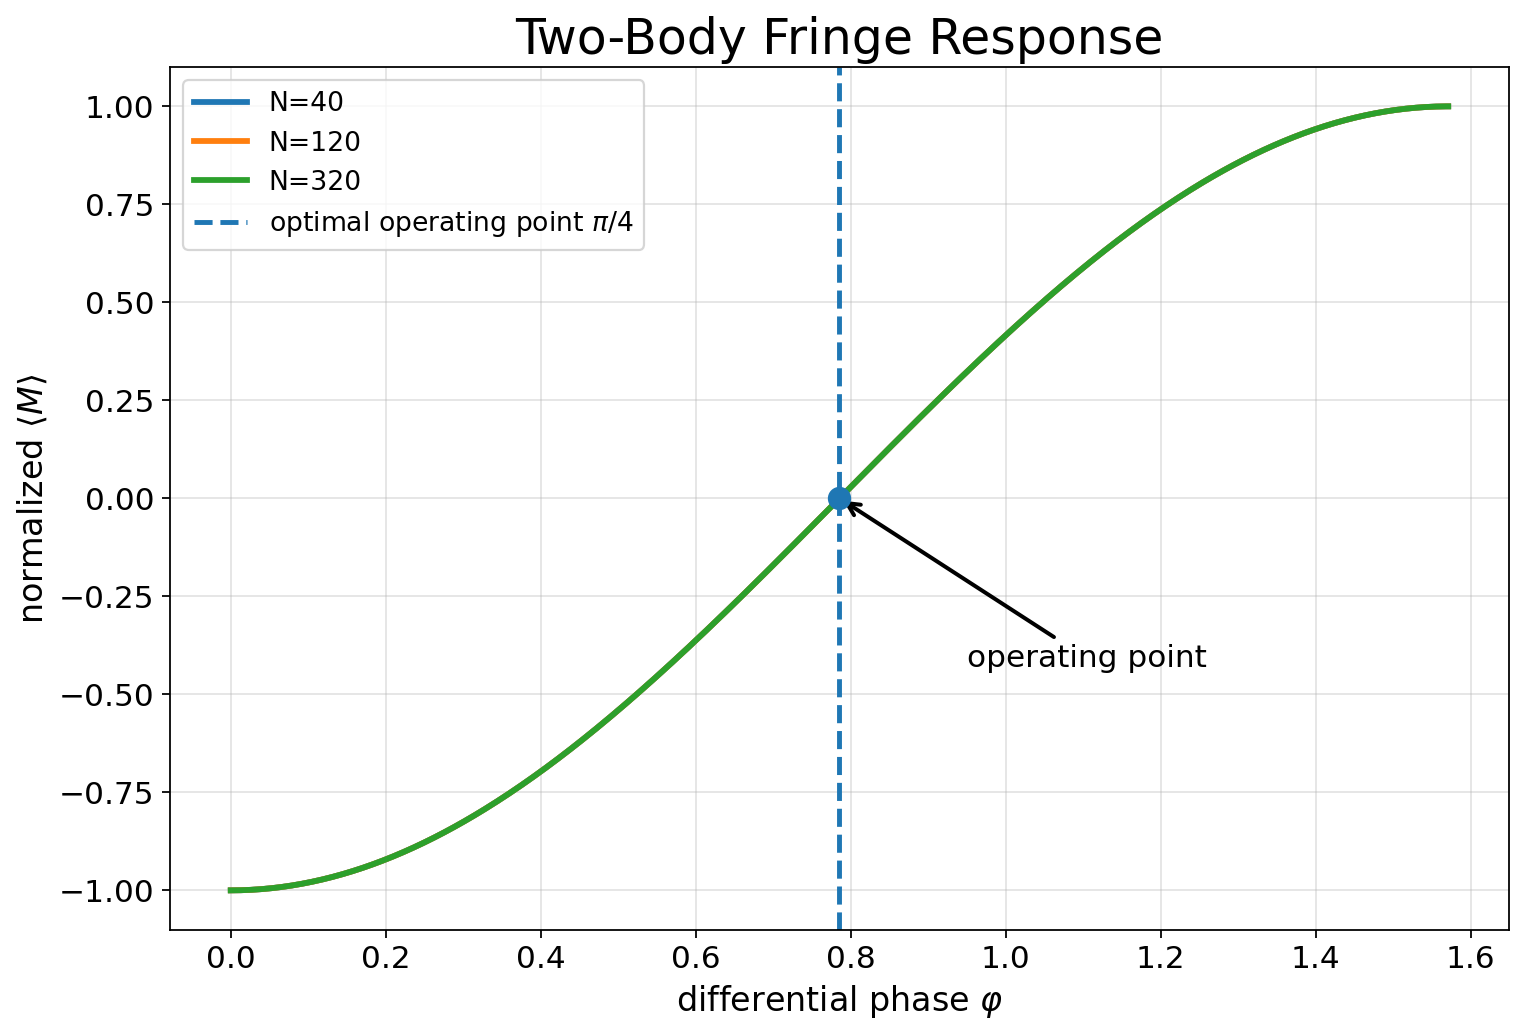

PosixPath('/content/results/figures/37_two_body_fringe_response_final.png')

In [53]:
phi = np.linspace(0, np.pi/2, 600)
op = np.pi / 4
fringe = np.sin(2 * phi - np.pi/2)

fig, ax = plt.subplots(figsize=(10.8, 7.0))
for N in [40, 120, 320]:
    ax.plot(phi, fringe, linewidth=2.6, label=f"N={N}")

ax.axvline(op, linestyle="--", linewidth=2.2, label=r"optimal operating point $\pi/4$")
ax.scatter([op], [np.sin(2*op - np.pi/2)], s=90, zorder=5)
ax.annotate(
    "operating point",
    xy=(op, np.sin(2*op - np.pi/2)),
    xytext=(0.95, -0.43),
    arrowprops=dict(arrowstyle="->", linewidth=1.8),
    fontsize=14,
)

ax.set_title("Two-Body Fringe Response")
ax.set_xlabel(r"differential phase $\varphi$")
ax.set_ylabel(r"normalized $\langle M\rangle$")
ax.grid(True, alpha=0.35)
ax.legend(loc="upper left")

path = savefig("37_two_body_fringe_response_final.png")
plt.show()
path


## 3. Measurement slope

The local information comes from the response slope:

\[
\left|\frac{d\langle M\rangle}{d\varphi}\right|
=
2|\cos(2\varphi-\pi/2)|.
\]

The measurement is most useful where this slope is largest. In this convention, that operating point is \(\pi/4\).


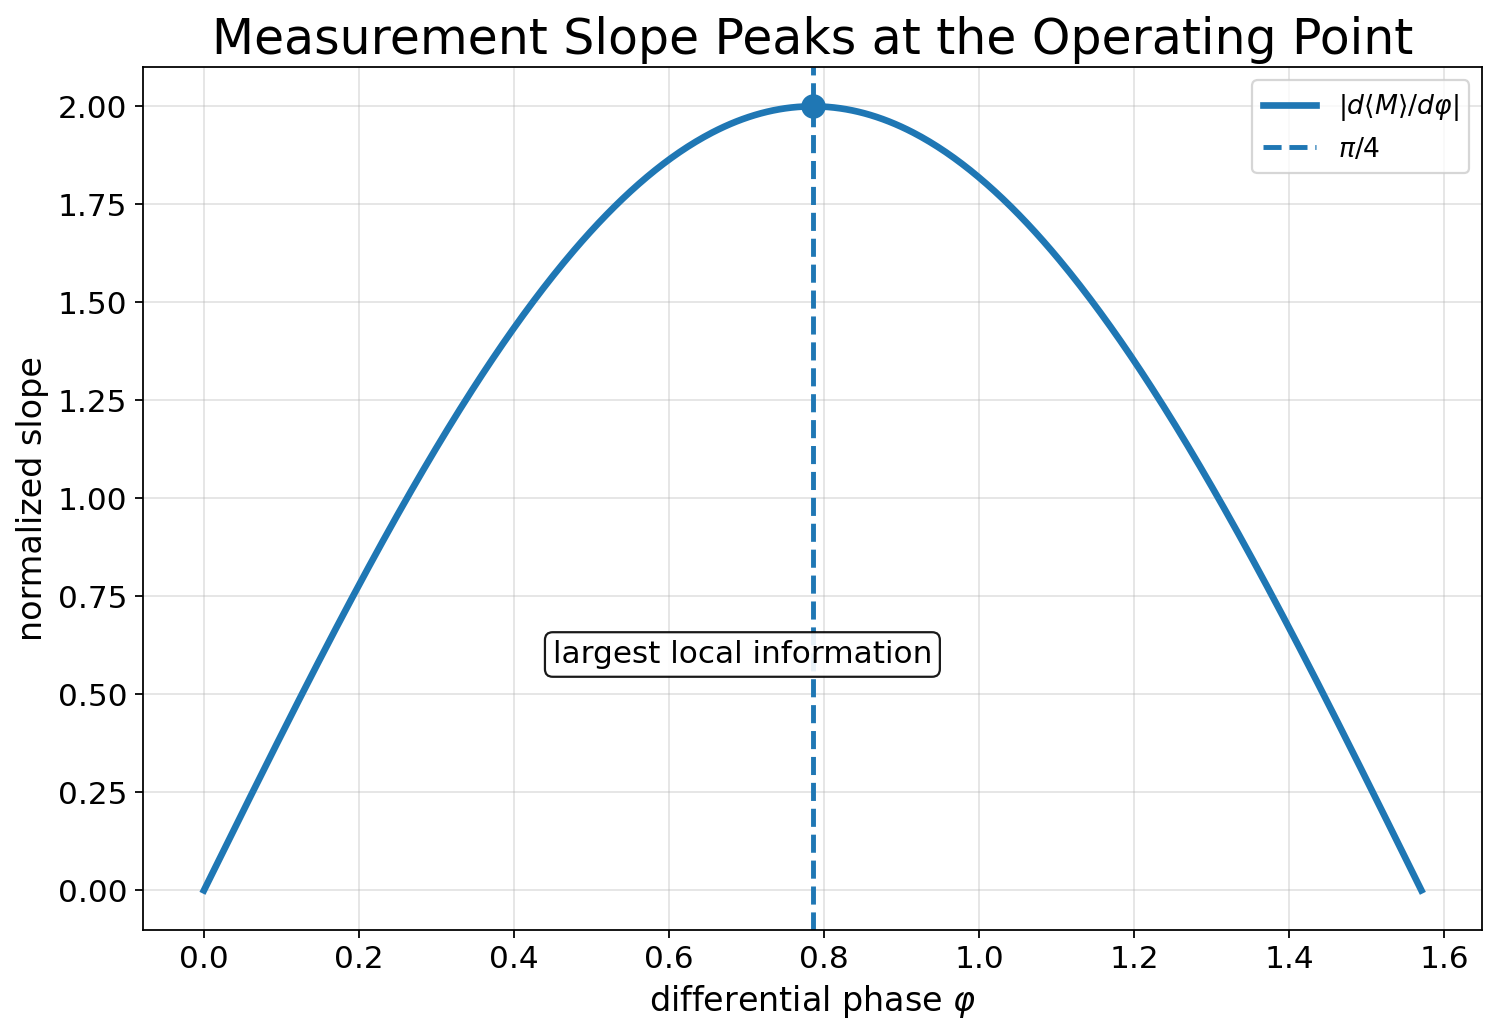

PosixPath('/content/results/figures/37_measurement_slope_final.png')

In [54]:
slope = np.abs(2 * np.cos(2 * phi - np.pi/2))

fig, ax = plt.subplots(figsize=(10.8, 7.0))
ax.plot(phi, slope, linewidth=3, label=r"$|d\langle M\rangle/d\varphi|$")
ax.axvline(op, linestyle="--", linewidth=2.2, label=r"$\pi/4$")
ax.scatter([op], [2], s=100, zorder=5)
ax.text(
    0.45, 0.58, "largest local information",
    fontsize=14,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.9),
)

ax.set_title("Measurement Slope Peaks at the Operating Point")
ax.set_xlabel(r"differential phase $\varphi$")
ax.set_ylabel("normalized slope")
ax.grid(True, alpha=0.35)
ax.legend(loc="upper right")

path = savefig("37_measurement_slope_final.png")
plt.show()
path


## 4. Operating regimes

Poor operating regions have low slope and therefore convert the same measurement variance into larger phase uncertainty.

The operating point is chosen at the maximum-information region.


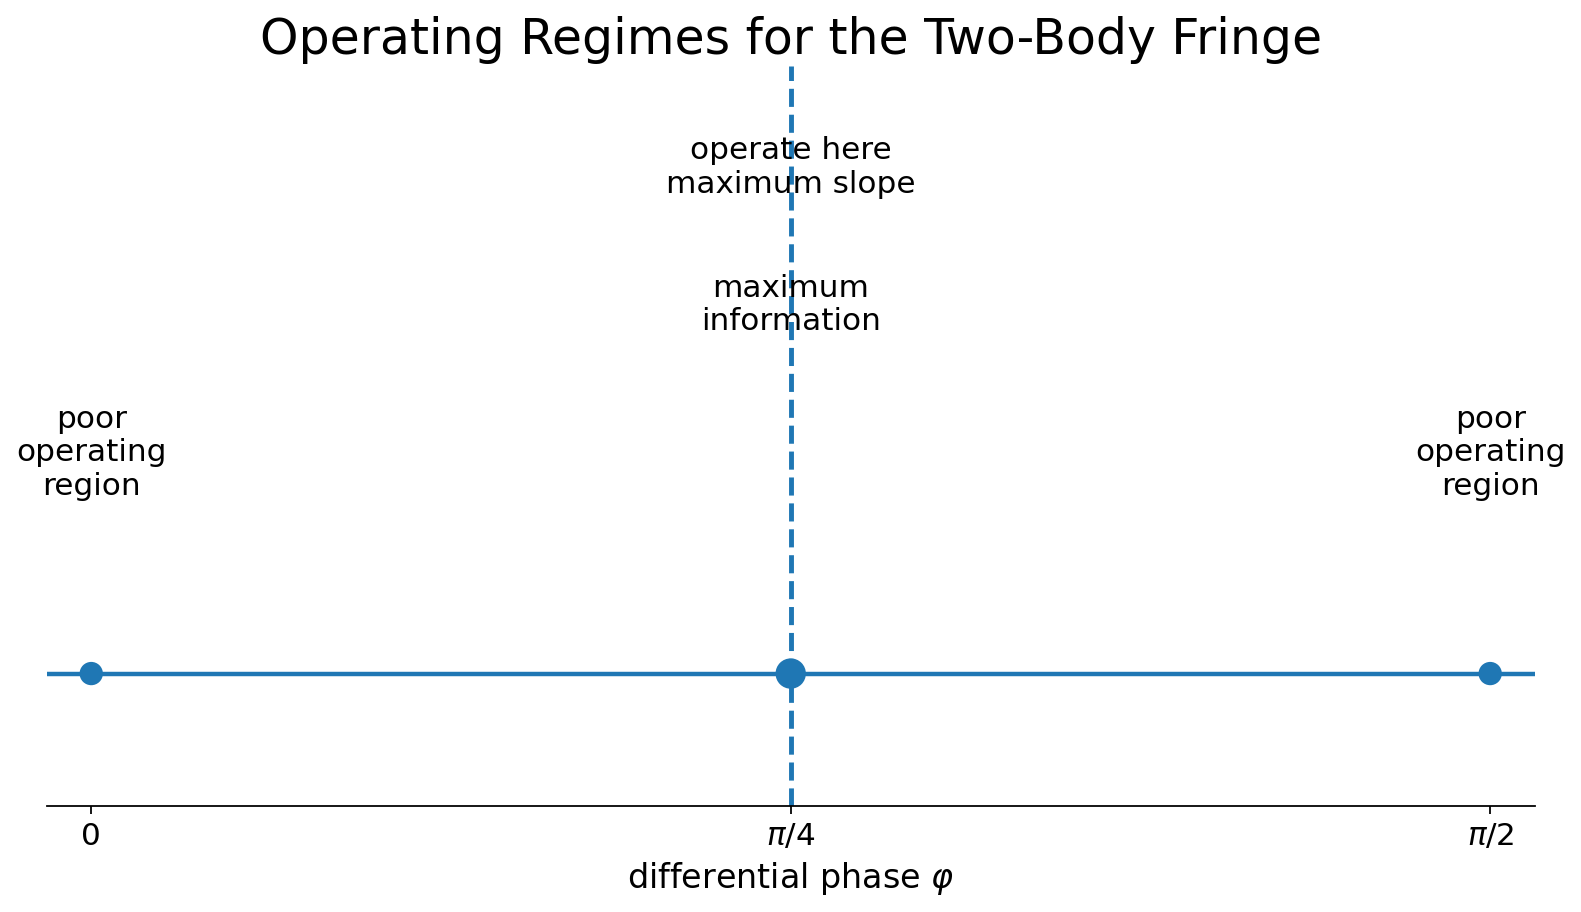

PosixPath('/content/results/figures/37_operating_regimes_final.png')

In [55]:
fig, ax = plt.subplots(figsize=(12.0, 6.0))
ax.set_title("Operating Regimes for the Two-Body Fringe")
ax.set_xlim(-0.05, np.pi/2 + 0.05)
ax.set_ylim(-0.25, 1.15)
ax.axhline(0, linewidth=2)
ax.scatter([0, op, np.pi/2], [0, 0, 0], s=[90, 160, 90], zorder=5)
ax.axvline(op, linestyle="--", linewidth=2.2)

ax.text(0, 0.42, "poor\noperating\nregion", ha="center", va="center", fontsize=14)
ax.text(op, 0.70, "maximum\ninformation", ha="center", va="center", fontsize=14)
ax.text(np.pi/2, 0.42, "poor\noperating\nregion", ha="center", va="center", fontsize=14)
ax.text(op, 0.96, "operate here\nmaximum slope", ha="center", va="center", fontsize=14)

ax.set_xticks([0, op, np.pi/2])
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.set_yticks([])
ax.set_xlabel(r"differential phase $\varphi$")
for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

path = savefig("37_operating_regimes_final.png")
plt.show()
path


## 5. Measurement readout

Measurement statistics become phase precision through local error propagation:

\[
\Delta^2\varphi
=
\frac{\Delta^2 M}{|\partial_\varphi\langle M\rangle|^2}.
\]

The same measurement variance produces lower phase uncertainty when the local response slope is larger.


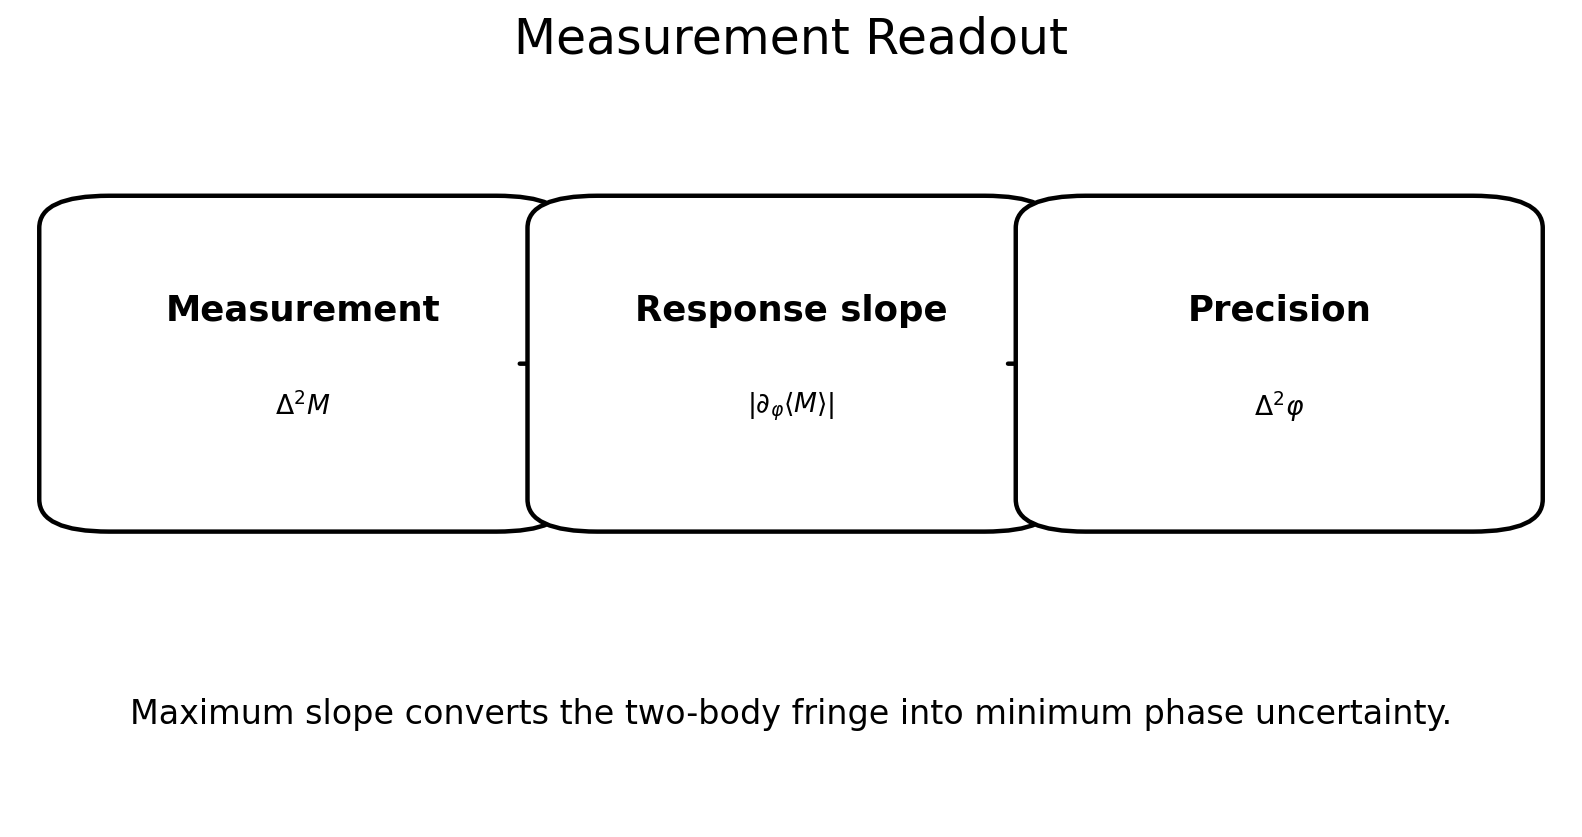

PosixPath('/content/results/figures/37_measurement_readout_final.png')

In [56]:
draw_box_flow(
    title="Measurement Readout",
    boxes=[
        {"title": "Measurement", "body": r"$\Delta^2 M$"},
        {"title": "Response slope", "body": r"$|\partial_\varphi\langle M\rangle|$"},
        {"title": "Precision", "body": r"$\Delta^2\varphi$"},
    ],
    footer="Maximum slope converts the two-body fringe into minimum phase uncertainty.",
    filename="37_measurement_readout_final.png",
    figsize=(12.5, 5.8),
)


## 6. Numerical error-propagation proxy

Use a simple bounded-observable variance proxy:

\[
\Delta^2 M(\varphi) \approx 1-\langle M\rangle(\varphi)^2.
\]

The phase uncertainty proxy is

\[
\Delta^2\varphi(\varphi)
\approx
\frac{1-\langle M\rangle(\varphi)^2}
{|\partial_\varphi\langle M\rangle|^2+\epsilon}.
\]

This isolates the design rule: do not operate where the response slope is near zero.


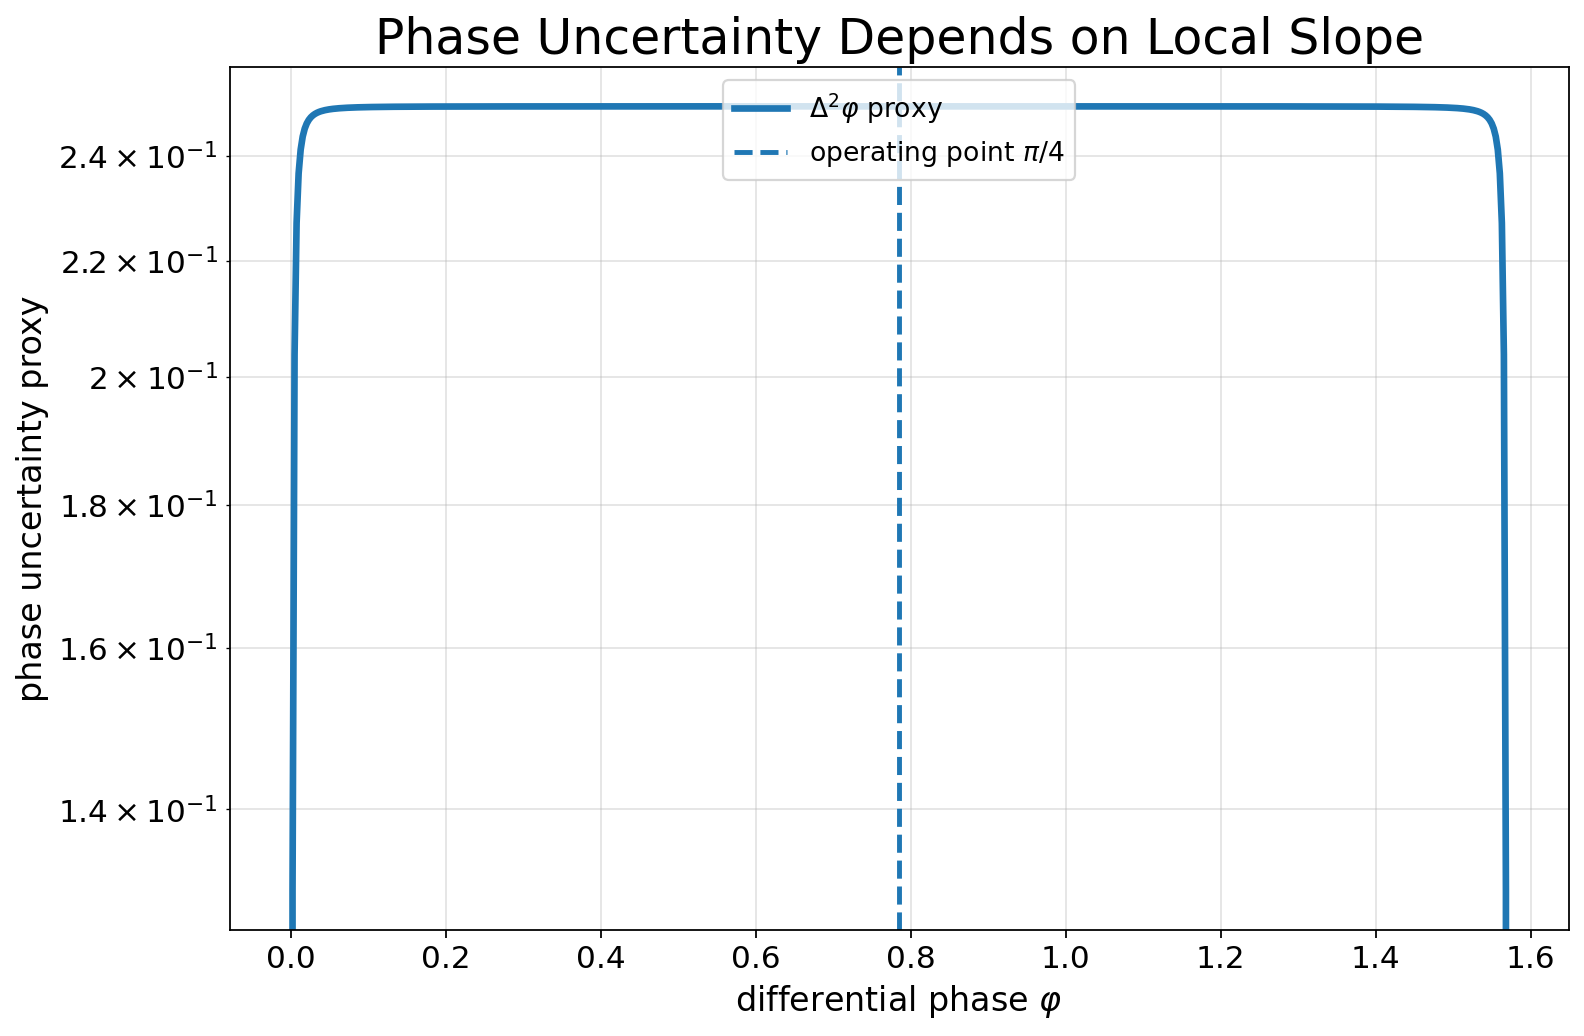

PosixPath('/content/results/figures/37_phase_uncertainty_proxy_final.png')

In [57]:
eps = 1e-4
mean_M = fringe
var_M = 1 - mean_M**2
phase_var = var_M / (slope**2 + eps)

fig, ax = plt.subplots(figsize=(10.8, 7.0))
ax.plot(phi, phase_var, linewidth=3, label=r"$\Delta^2\varphi$ proxy")
ax.axvline(op, linestyle="--", linewidth=2.2, label=r"operating point $\pi/4$")
ax.set_yscale("log")
ax.set_title("Phase Uncertainty Depends on Local Slope")
ax.set_xlabel(r"differential phase $\varphi$")
ax.set_ylabel("phase uncertainty proxy")
ax.grid(True, which="both", alpha=0.35)
ax.legend(loc="upper center")

path = savefig("37_phase_uncertainty_proxy_final.png")
plt.show()
path


## 7. Summary table


In [58]:
summary = pd.DataFrame([
    {
        "stage": "DFS state",
        "specification": "J_z^+ = 0",
        "engineering_role": "common-mode phase remains rejected",
    },
    {
        "stage": "Differential generator",
        "specification": "J_z^-",
        "engineering_role": "useful signal coordinate",
    },
    {
        "stage": "Observable",
        "specification": "[M, J_z^+] = 0",
        "engineering_role": "measurement does not leak the DFS",
    },
    {
        "stage": "Fringe",
        "specification": "<M>(varphi)",
        "engineering_role": "maps phase into readout",
    },
    {
        "stage": "Slope",
        "specification": "|d<M>/dvarphi|",
        "engineering_role": "local information",
    },
    {
        "stage": "Error propagation",
        "specification": "Delta^2 varphi = Delta^2 M / slope^2",
        "engineering_role": "measurement uncertainty becomes phase uncertainty",
    },
])

summary_csv = RESULTS / "two_body_measurement_summary.csv"
summary_json = RESULTS / "two_body_measurement_summary.json"

summary.to_csv(summary_csv, index=False)
summary.to_json(summary_json, orient="records", indent=2)

summary


,stage,specification,engineering_role
0,DFS state,J_z^+ = 0,common-mode phase remains rejected
1,Differential generator,J_z^-,useful signal coordinate
2,Observable,"[M, J_z^+] = 0",measurement does not leak the DFS
3,Fringe,<M>(varphi),maps phase into readout
4,Slope,|d<M>/dvarphi|,local information
5,Error propagation,Delta^2 varphi = Delta^2 M / slope^2,measurement uncertainty becomes phase uncertainty


## 8. Export notebook outputs

Run the next cell after the figures have been generated.

It writes a zip archive containing all generated figures plus the summary table, then displays a clickable notebook link.


In [62]:
from pathlib import Path
import zipfile

zip_path = ROOT / "37_two_body_measurement_figures.zip"

figure_files = sorted(FIGURES.glob("37_*.png"))

if not figure_files:
    raise FileNotFoundError(f"No figures found in {FIGURES}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for png in figure_files:
        zf.write(png, arcname=png.name)

print(f"Created {zip_path} with {len(figure_files)} figures")

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    from IPython.display import FileLink, display
    display(FileLink(str(zip_path)))

Created /content/37_two_body_measurement_figures.zip with 11 figures


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Next notebook

Suggested next notebook:

`43_preparation_protocols.ipynb`

Core goal:

- compare routes for preparing useful DFS-compatible entanglement,
- connect measurement requirements to preparation requirements,
- organize unitary, dissipative, and measurement-conditioned pathways,
- close the loop from specification to implementation.
